In [358]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OrdinalEncoder
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

df = pd.read_csv("youtube_videos.csv")

df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


In [359]:
scaler = MinMaxScaler()

df["subscribers_minmax"] = scaler.fit_transform(df[["subscribers"]])

df["subscribers"].describe()

count    2.100000e+02
mean     1.005263e+06
std      2.063624e+06
min      5.624000e+03
25%      2.544875e+04
50%      1.359100e+05
75%      4.862028e+05
max      7.763623e+06
Name: subscribers, dtype: float64

In [360]:
standard_scaler = StandardScaler()

In [361]:
df["views_zscore"] = standard_scaler.fit_transform(df[["views"]])

In [362]:
df[["views", "views_zscore"]].describe()

,views,views_zscore
count,2.100000e+02,2.100000e+02
mean,5.485440e+05,2.537653e-17
std,1.223751e+06,1.002389e+00
min,1.412000e+03,-4.481625e-01
25%,1.080400e+04,-4.404694e-01
50%,6.597350e+04,-3.952794e-01
75%,3.108772e+05,-1.946757e-01
max,7.038551e+06,5.316044e+00


In [363]:
df["views_log"] = np.log1p(df["views"])
df["views_log"]

0      12.337553
1      10.129786
2      14.096130
3      12.142883
4       9.440181
         ...    
205     8.770594
206     8.467162
207    11.560315
208     8.015327
209    11.884806
Name: views_log, Length: 210, dtype: float64

<Axes: xlabel='views', ylabel='Count'>

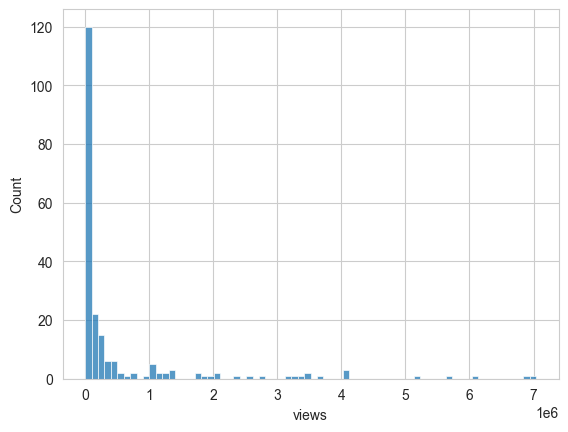

In [364]:
sns.histplot(df["views"])

In [365]:
bins = [0, 6, 12, 17, 21, 24]
labels = ["midnight", "morning", "afternoon", "evening", "night"]

df["upload_hour_bin"] = pd.cut(df["upload_hour"], bins=bins, labels=labels)

<Axes: xlabel='upload_hour', ylabel='count'>

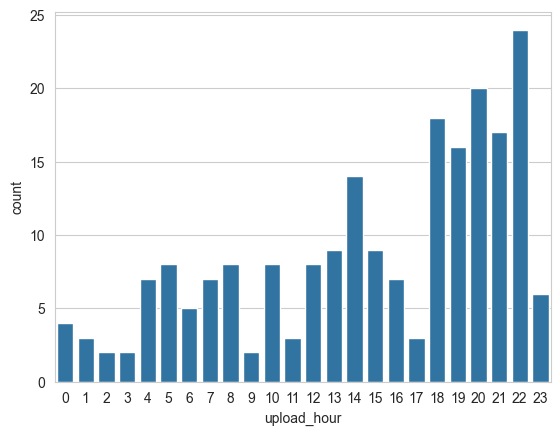

In [366]:
sns.countplot(x="upload_hour", data=df)

In [367]:
df["channel_tier"].unique()
encoder = OrdinalEncoder(categories=[['Small', 'Mid', 'Large']])
df[["channel_tier_encoded"]] = encoder.fit_transform(df[["channel_tier"]]).astype(int)
df[["channel_tier", "channel_tier_encoded"]]

,channel_tier,channel_tier_encoded
0,Mid,1
1,Small,0
2,Large,2
3,Mid,1
4,Small,0
...,...,...
205,Small,0
206,Small,0
207,Mid,1
208,Small,0


In [368]:
dummyVars = pd.get_dummies(df["category"], prefix="is")
dummyVars

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
205,False,True,False,False,False,False
206,False,False,False,False,True,False
207,False,False,True,False,False,False
208,True,False,False,False,False,False


In [369]:
df = pd.concat([df, dummyVars], axis=1)
df

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,...,views_zscore,views_log,upload_hour_bin,channel_tier_encoded,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,...,-0.262478,12.337553,NaN,1,False,False,False,True,False,False
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,...,-0.428777,10.129786,evening,0,False,False,True,False,False,False
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,...,0.635144,14.096130,evening,2,False,False,True,False,False,False
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,...,-0.295529,12.142883,afternoon,1,False,False,True,False,False,False
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,...,-0.439012,9.440181,midnight,0,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,vid_0205,STOP using Python for AI WRONG (most people do...,Education,Small,Friday,13,1737,6441,147,52,...,-0.444043,8.770594,afternoon,0,False,True,False,False,False,False
206,vid_0206,I built a machine learning pipelines project —...,News,Small,Saturday,8,5776,4755,249,63,...,-0.445424,8.467162,morning,0,False,False,False,False,True,False
207,vid_0207,What nobody tells you about Gemini,Gaming,Mid,Sunday,20,2617,104852,921,1069,...,-0.363434,11.560315,evening,1,False,False,True,False,False,False
208,vid_0208,Why deep learning frameworks DESTROYED my work...,Comedy,Small,Thursday,21,3656,3026,165,48,...,-0.446840,8.015327,evening,0,True,False,False,False,False,False


In [370]:
day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}
rng = np.random.default_rng(42)
base = pd.Timestamp("2024-01-01")

df["uploaded_at"] = [
    base
    + pd.offsets.Week(weekday=day_map[d])
    + pd.Timedelta(hours=int(h))
    + pd.Timedelta(minutes=int(rng.integers(0, 60)))
    for d, h in zip(df["upload_day"], df["upload_hour"])
]

df["uploaded_at"]

0     2024-01-07 00:05:00
1     2024-01-06 21:46:00
2     2024-01-08 18:39:00
3     2024-01-04 14:26:00
4     2024-01-08 04:25:00
              ...        
205   2024-01-05 13:15:00
206   2024-01-06 08:45:00
207   2024-01-07 20:58:00
208   2024-01-04 21:15:00
209   2024-01-05 10:46:00
Name: uploaded_at, Length: 210, dtype: datetime64[ns]

In [371]:
df["uploaded_at"].dt.dayofweek

0      6
1      5
2      0
3      3
4      0
      ..
205    4
206    5
207    6
208    3
209    4
Name: uploaded_at, Length: 210, dtype: int32

In [372]:
df["caps_count"]= df["title"].apply(
    lambda t: sum(1 for w in t.split() if w.isupper())
)

df["caps_count"]

0      3
1      1
2      0
3      0
4      4
      ..
205    3
206    2
207    0
208    2
209    3
Name: caps_count, Length: 210, dtype: int64

In [373]:
def countCaps(t):
    sum = 0
    words = t.split()
    for word in words:
        if word.isupper():
            sum = sum + 1
    return sum

df["caps_count"] = df["title"].apply(
    countCaps
)

df["lower_count"] = df["title"].apply(
    lambda t: sum(1 for w in t.split() if w.islower())
)

df["lower_count"]

0      6
1      6
2      7
3      3
4      5
      ..
205    6
206    9
207    4
208    9
209    3
Name: lower_count, Length: 210, dtype: int64

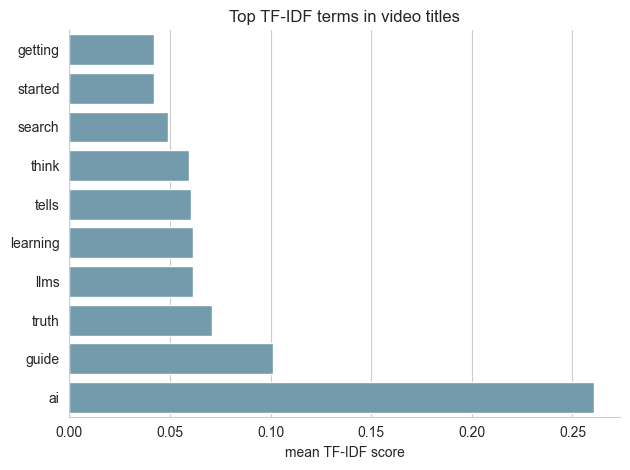

In [374]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv("youtube_videos.csv")

vectorizer = TfidfVectorizer(max_features=10, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df["title"])

terms = vectorizer.get_feature_names_out()
mean_scores = tfidf_matrix.toarray().mean(axis=0)

tfidf_df = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=True)

sns.barplot(data=tfidf_df,
            x="mean_tfidf",
            y="term",
            color="#6a9fb5")

plt.title("Top TF-IDF terms in video titles")
plt.xlabel("mean TF-IDF score")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

In [375]:
df["duration_minutes"] = df["duration_seconds"] / 60
df["retention_rate"] = df["watch_time_minutes"] / (df["views"] * df["duration_minutes"])

df["retention_rate"]

0      0.398058
1      0.535375
2      0.415428
3      0.483146
4      0.396453
         ...   
205    0.469772
206    0.289126
207    0.495605
208    0.528993
209    0.434620
Name: retention_rate, Length: 210, dtype: float64

In [376]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("youtube_videos.csv")

df["hashtags"] = df["hashtags"].apply(json.loads)

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
hashtag_encoded = pd.DataFrame(
    mlb.fit_transform(df["hashtags"]),
    columns=mlb.classes_,
    index=df.index
)

result = pd.concat([df[["video_id"]], hashtag_encoded], axis=1)
print(result.head(4).to_string(index=False))

video_id  ai  chatgpt  comedy  datascience  deeplearning  explained  gaming  howto  llm  machinelearning  music  news  python  review  shorts  tech  trending  tutorial  viral  vlog
vid_0000   1        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         1         1      0     0
vid_0001   0        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         0         1      0     0
vid_0002   0        0       0            0             0          1       0      0    0                0      0     0       0       0       0     0         0         0      0     0
vid_0003   0        0       0            0             0          1       1      0    0                0      0     0       0       0       0     1         1         0      0     0
